In [1]:
from pathlib import Path
print(Path.cwd())

/home/david/thesis


In [2]:
import pandas as pd

df = pd.read_csv("/home/david/thesis/data/processed/cr/ams02_proton_daily.csv")
df.head()

,date,rigidity_min_GV,rigidity_max_GV,flux,err_stat,err_time,err_sys
0,2011-05-20,1.00,1.16,999.8,15.7,10.0,29.3
1,2011-05-20,1.16,1.33,974.9,7.5,7.1,22.2
2,2011-05-20,1.33,1.51,914.4,6.7,5.0,17.1
3,2011-05-20,1.51,1.71,840.4,5.8,3.8,13.5
4,2011-05-20,1.71,1.92,739.4,4.9,3.1,10.7


In [3]:
print(df.columns.tolist())

['date', 'rigidity_min_GV', 'rigidity_max_GV', 'flux', 'err_stat', 'err_time', 'err_sys']


In [4]:
print(df.shape)

(83757, 7)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83757 entries, 0 to 83756
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             83757 non-null  str    
 1   rigidity_min_GV  83757 non-null  float64
 2   rigidity_max_GV  83757 non-null  float64
 3   flux             83757 non-null  float64
 4   err_stat         83757 non-null  float64
 5   err_time         83757 non-null  float64
 6   err_sys          83757 non-null  float64
dtypes: float64(6), str(1)
memory usage: 4.5 MB


In [6]:
df = pd.read_csv("/home/david/thesis/data/cr/core/ams02_proton_daily.csv")
df.head()

,date YYYY-MM-DD,rigidity_min GV,rigidity_max GV,proton_flux m^-2sr^-1s^-1GV^-1,proton_flux_error_statistical m^-2sr^-1s^-1GV^-1,proton_flux_error_timedependent m^-2sr^-1s^-1GV^-1,proton_flux_error_systematic_total m^-2sr^-1s^-1GV^-1
0,2011-05-20,1.00,1.16,999.8,15.7,10.0,29.3
1,2011-05-20,1.16,1.33,974.9,7.5,7.1,22.2
2,2011-05-20,1.33,1.51,914.4,6.7,5.0,17.1
3,2011-05-20,1.51,1.71,840.4,5.8,3.8,13.5
4,2011-05-20,1.71,1.92,739.4,4.9,3.1,10.7


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

df = pd.read_csv("/home/david/thesis/data/processed/cr/ams02_proton_daily.csv")
df["date"] = pd.to_datetime(df["date"])

df["rigidity_mid_GV"] = 0.5 * (df["rigidity_min_GV"] + df["rigidity_max_GV"])
df["sigma_tot"] = np.sqrt(df["err_stat"]**2 + df["err_time"]**2 + df["err_sys"]**2)

df.head()

,date,rigidity_min_GV,rigidity_max_GV,flux,err_stat,err_time,err_sys,rigidity_mid_GV,sigma_tot
0,2011-05-20,1.00,1.16,999.8,15.7,10.0,29.3,1.080,34.712822
1,2011-05-20,1.16,1.33,974.9,7.5,7.1,22.2,1.245,24.484689
2,2011-05-20,1.33,1.51,914.4,6.7,5.0,17.1,1.420,19.034180
3,2011-05-20,1.51,1.71,840.4,5.8,3.8,13.5,1.610,15.176627
4,2011-05-20,1.71,1.92,739.4,4.9,3.1,10.7,1.815,12.170045


In [8]:
summary = (
    df.groupby(["rigidity_min_GV", "rigidity_max_GV", "rigidity_mid_GV"])
      .agg(
          N=("flux", "size"),
          mean_flux=("flux", "mean"),
          min_flux=("flux", "min"),
          max_flux=("flux", "max"),
          std_flux=("flux", "std"),
          mean_sigma_tot=("sigma_tot", "mean")
      )
      .reset_index()
      .sort_values("rigidity_mid_GV")
)

summary["A"] = (summary["max_flux"] - summary["min_flux"]) / summary["mean_flux"]
summary["A_p"] = (
    df.groupby(["rigidity_min_GV", "rigidity_max_GV", "rigidity_mid_GV"])["flux"]
      .apply(lambda x: (np.percentile(x, 95) - np.percentile(x, 5)) / x.mean())
      .values
)
summary["A_rms"] = (
    df.groupby(["rigidity_min_GV", "rigidity_max_GV", "rigidity_mid_GV"])["flux"]
      .apply(lambda x: x.std(ddof=1) / x.mean())
      .values
)

summary.head(10)

,rigidity_min_GV,rigidity_max_GV,rigidity_mid_GV,N,mean_flux,min_flux,max_flux,std_flux,mean_sigma_tot,A,A_p,A_rms
0,1.00,1.16,1.080,2717,940.711630,346.7,1824.0,429.451403,28.864595,1.570407,1.350998,0.456518
1,1.16,1.33,1.245,2717,908.801693,363.7,1661.0,378.254765,21.691601,1.427484,1.226296,0.416213
2,1.33,1.51,1.420,2717,852.945970,370.8,1471.0,322.057417,16.697732,1.289882,1.105697,0.377582
3,1.51,1.71,1.610,2717,780.292234,368.0,1275.0,266.380128,13.141574,1.162385,0.989783,0.341385
4,1.71,1.92,1.815,2717,694.664630,349.7,1088.0,213.020312,10.509708,1.062815,0.885463,0.306652
5,1.92,2.15,2.035,2717,608.418881,327.2,908.4,167.729511,8.497498,0.955263,0.793927,0.275681
6,2.15,2.40,2.275,2717,525.292124,304.6,754.1,129.842119,6.951550,0.855714,0.710348,0.247181
7,2.40,2.67,2.535,2717,447.286014,274.2,619.6,98.664619,5.628063,0.772213,0.633241,0.220585
8,2.67,2.97,2.820,2717,377.780272,246.0,505.5,74.102783,4.595615,0.686907,0.563926,0.196153
9,2.97,3.29,3.130,2824,315.493555,197.7,411.6,55.206779,3.754234,0.677985,0.506777,0.174985


In [9]:
rho_A, p_A = spearmanr(summary["rigidity_mid_GV"], summary["A"])
rho_Ap, p_Ap = spearmanr(summary["rigidity_mid_GV"], summary["A_p"])
rho_Arms, p_Arms = spearmanr(summary["rigidity_mid_GV"], summary["A_rms"])

print("Spearman rho for A     =", rho_A, " p =", p_A)
print("Spearman rho for A_p   =", rho_Ap, " p =", p_Ap)
print("Spearman rho for A_rms =", rho_Arms, " p =", p_Arms)

Spearman rho for A     = -0.9986651835372636  p = 1.384484298629843e-37
Spearman rho for A_p   = -0.9968854282536151  p = 1.942089591080761e-32
Spearman rho for A_rms = -0.9968854282536151  p = 1.942089591080761e-32


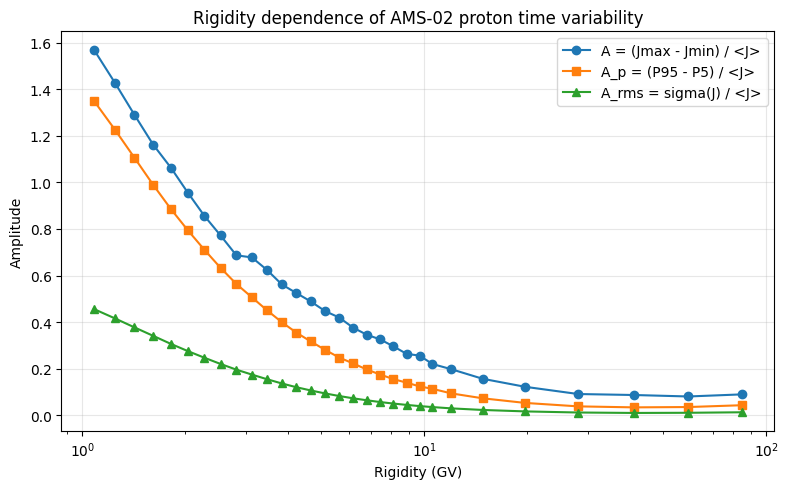

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(summary["rigidity_mid_GV"], summary["A"], marker="o", label="A = (Jmax - Jmin) / <J>")
plt.plot(summary["rigidity_mid_GV"], summary["A_p"], marker="s", label="A_p = (P95 - P5) / <J>")
plt.plot(summary["rigidity_mid_GV"], summary["A_rms"], marker="^", label="A_rms = sigma(J) / <J>")

plt.xscale("log")
plt.xlabel("Rigidity (GV)")
plt.ylabel("Amplitude")
plt.title("Rigidity dependence of AMS-02 proton time variability")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

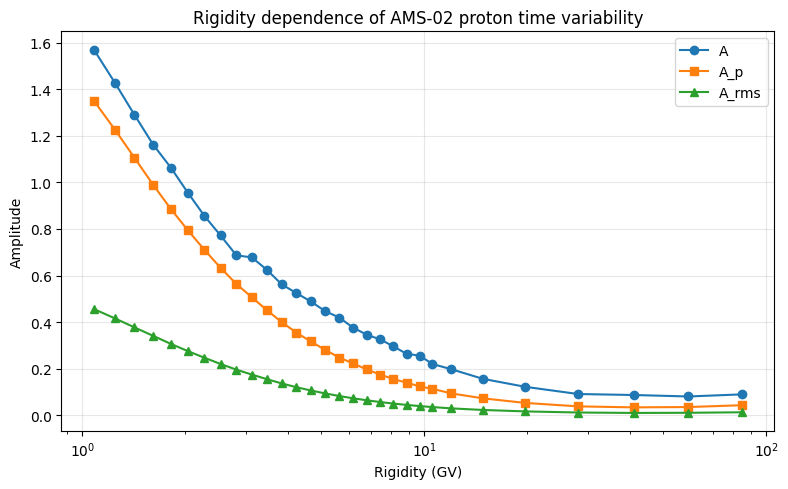

In [11]:
summary.to_csv("/home/david/thesis/outputs/tables/ams02_rigidity_dependence_summary.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(summary["rigidity_mid_GV"], summary["A"], marker="o", label="A")
plt.plot(summary["rigidity_mid_GV"], summary["A_p"], marker="s", label="A_p")
plt.plot(summary["rigidity_mid_GV"], summary["A_rms"], marker="^", label="A_rms")
plt.xscale("log")
plt.xlabel("Rigidity (GV)")
plt.ylabel("Amplitude")
plt.title("Rigidity dependence of AMS-02 proton time variability")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("/home/david/thesis/figures/ams02_rigidity_dependence_A.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
paper_table = summary[[
    "rigidity_min_GV", "rigidity_max_GV", "rigidity_mid_GV",
    "N", "A", "A_p", "A_rms"
]].copy()

paper_table.head(15)

,rigidity_min_GV,rigidity_max_GV,rigidity_mid_GV,N,A,A_p,A_rms
0,1.00,1.16,1.080,2717,1.570407,1.350998,0.456518
1,1.16,1.33,1.245,2717,1.427484,1.226296,0.416213
2,1.33,1.51,1.420,2717,1.289882,1.105697,0.377582
3,1.51,1.71,1.610,2717,1.162385,0.989783,0.341385
4,1.71,1.92,1.815,2717,1.062815,0.885463,0.306652
5,1.92,2.15,2.035,2717,0.955263,0.793927,0.275681
6,2.15,2.40,2.275,2717,0.855714,0.710348,0.247181
7,2.40,2.67,2.535,2717,0.772213,0.633241,0.220585
8,2.67,2.97,2.820,2717,0.686907,0.563926,0.196153
9,2.97,3.29,3.130,2824,0.677985,0.506777,0.174985
